In [9]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import *
from imblearn.over_sampling import SMOTE
import warnings; warnings.filterwarnings('ignore')

In [10]:
df = pd.read_csv('framingham.csv') # file upload kar do
print("Shape:", df.shape)
display(df.head())

Shape: (4238, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


Missing Values:
 male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Target Distribution:
 TenYearCHD
0    3594
1     644
Name: count, dtype: int64


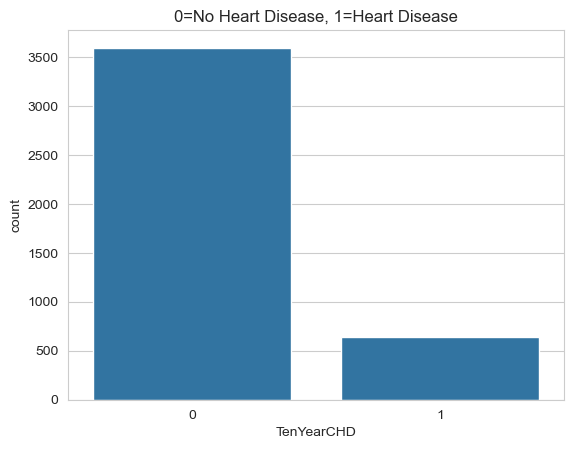

In [11]:
print("Missing Values:\n", df.isnull().sum())
print("\nTarget Distribution:\n", df['TenYearCHD'].value_counts())

sns.countplot(x='TenYearCHD', data=df)
plt.title("0=No Heart Disease, 1=Heart Disease"); plt.show()

In [12]:
# Missing values ko mean se fill karo
df = pd.DataFrame(SimpleImputer(strategy='mean').fit_transform(df), columns=df.columns)

X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

# Scaling
X = StandardScaler().fit_transform(X)
print("Preprocessing Done")

Preprocessing Done


In [13]:
print("Before SMOTE:", pd.Series(y).value_counts())
X, y = SMOTE(random_state=42).fit_resample(X, y)
print("After SMOTE:", pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Before SMOTE: TenYearCHD
0.0    3594
1.0     644
Name: count, dtype: int64
After SMOTE: TenYearCHD
0.0    3594
1.0    3594
Name: count, dtype: int64



LR
              precision    recall  f1-score   support

         0.0       0.70      0.66      0.68       752
         1.0       0.65      0.70      0.67       686

    accuracy                           0.68      1438
   macro avg       0.68      0.68      0.68      1438
weighted avg       0.68      0.68      0.68      1438



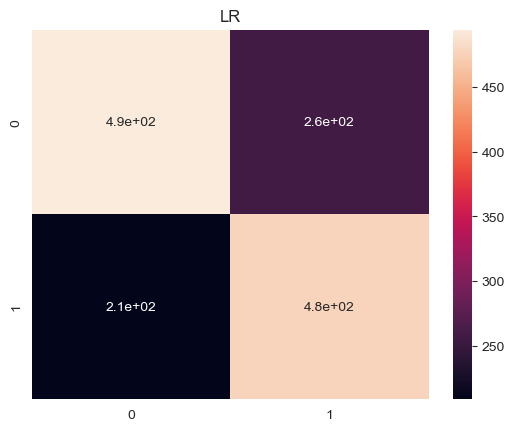


RF
              precision    recall  f1-score   support

         0.0       0.91      0.89      0.90       752
         1.0       0.88      0.90      0.89       686

    accuracy                           0.89      1438
   macro avg       0.89      0.89      0.89      1438
weighted avg       0.89      0.89      0.89      1438



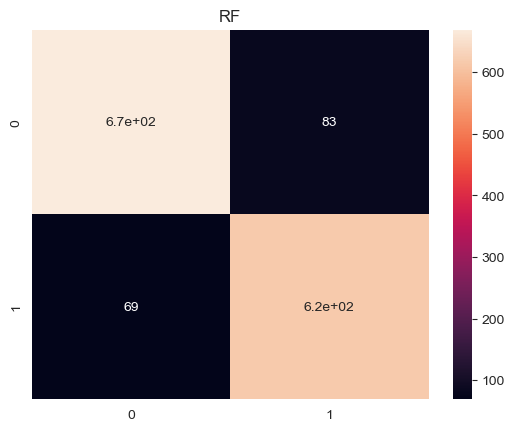


SVM
              precision    recall  f1-score   support

         0.0       0.76      0.70      0.73       752
         1.0       0.70      0.76      0.72       686

    accuracy                           0.73      1438
   macro avg       0.73      0.73      0.73      1438
weighted avg       0.73      0.73      0.73      1438



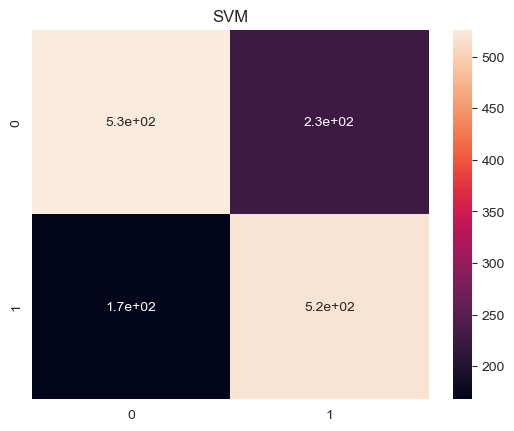

In [14]:
models = {"LR": LogisticRegression(max_iter=500),
          "RF": RandomForestClassifier(),
          "SVM": SVC()}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = [accuracy_score(y_test,y_pred), precision_score(y_test,y_pred),
                     recall_score(y_test,y_pred), f1_score(y_test,y_pred)]

    print(f"\n{name}")
    print(classification_report(y_test,y_pred))
    sns.heatmap(confusion_matrix(y_test,y_pred), annot=True); plt.title(name); plt.show()

In [15]:
results_df = pd.DataFrame(results, index=['Acc','Prec','Rec','F1']).T
display(results_df)
best = results_df['Acc'].idxmax()
print("\nBest Model:", best)

,Acc,Prec,Rec,F1
LR,0.675243,0.648980,0.695335,0.671358
RF,0.894298,0.881429,0.899417,0.890332
SVM,0.726008,0.696237,0.755102,0.724476



Best Model: RF


In [16]:
print(f"\nTuning {best}...")
grid = GridSearchCV(RandomForestClassifier(), {'n_estimators':[100,200]}, cv=5).fit(X_train,y_train)
print("Best Params:", grid.best_params_)
print("Best Accuracy after Tuning:", round(grid.best_score_,4))


Tuning RF...
Best Params: {'n_estimators': 200}
Best Accuracy after Tuning: 0.8889
